# 🦷 RetinaNet — Dental X-Ray Object Detection
**Dataset:** Cavity · Fillings · Impacted Tooth · Implant  
**Backbone:** ResNet-50-v2 + FPN (pretrained ImageNet)  
**Augmentation:** On-the-fly oversampling → 2 000 samples/class (skip if ≥ 1 500)  
**Improvements:** AMP · Cosine LR · Early Stopping · Dynamic conf threshold · Dental augmentations  
**Visualisations:** Loss · mAP · P/R/F1 vs Epoch · PR-Curve · F1-Confidence · Confusion Matrix · Dashboard

In [5]:
# ── Install ────────────────────────────────────────────────────────────────────
!pip install pycocotools albumentations -q


In [6]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os, json, copy, random, time, cv2, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import (
    retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights
)
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42); random.seed(42)

print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")


PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
CUDA        : True


In [7]:
# ── Configuration ─────────────────────────────────────────────────────────────
BASE = '/kaggle/input/datasets/yousseforabi/dental-xray-coco'          # ← your Kaggle dataset path

CFG = dict(
    train_json    = f'{BASE}/train/_annotations.coco.json',
    val_json      = f'{BASE}/valid/_annotations.coco.json',
    test_json     = f'{BASE}/test/_annotations.coco.json',

    train_img_dir = f'{BASE}/train',
    val_img_dir   = f'{BASE}/valid',
    test_img_dir  = f'{BASE}/test',

    num_classes   = 4,
    class_names   = ['Background', 'Cavity', 'Fillings', 'Impacted Tooth', 'Implant'],

    # augmentation
    aug_target    = 2000,   # target samples per class
    aug_threshold = 1500,   # skip augmentation if class already >= this

    # training
    img_size       = 640,
    batch_size     = 4,
    num_workers    = 2,
    num_epochs     = 50,
    lr             = 1e-4,
    weight_decay   = 1e-4,

    # early stopping
    patience       = 10,

    # inference (will be updated after training with optimal threshold)
    conf_threshold = 0.30,
    iou_threshold  = 0.50,

    device   = 'cuda' if torch.cuda.is_available() else 'cpu',
    save_dir = '/kaggle/working',
)

os.makedirs(CFG['save_dir'], exist_ok=True)
print(f"Device: {CFG['device']}")


Device: cuda


In [8]:
# # ── Dataset Analysis ──────────────────────────────────────────────────────────
# def get_class_counts(json_path):
#     with open(json_path) as f:
#         data = json.load(f)
#     cat_map  = {c['id']: c['name'] for c in data['categories']}
#     cat_ids  = sorted(cat_map.keys())
#     counts   = defaultdict(int)
#     for ann in data['annotations']:
#         counts[ann['category_id']] += 1
#     return {cat_map[cid]: counts[cid] for cid in cat_ids}, cat_map, cat_ids

# train_counts, cat_map, cat_ids = get_class_counts(CFG['train_json'])
# val_counts,   _,       _       = get_class_counts(CFG['val_json'])
# test_counts,  _,       _       = get_class_counts(CFG['test_json'])

# print(f"{'Class':<22} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
# print('─' * 52)
# for cls in CFG['class_names'][1:]:
#     tr = train_counts.get(cls, 0)
#     va = val_counts.get(cls, 0)
#     te = test_counts.get(cls, 0)
#     print(f"{cls:<22} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")

# # COCO category-id  ←→  model label (1-indexed, 0=background)
# with open(CFG['train_json']) as f:
#     _td = json.load(f)
# # CAT_TO_LABEL = {c['id']: i+1 for i, c in enumerate(sorted(_td['categories'], key=lambda x: x['id']))}
# # LABEL_TO_CAT = {v: k for k, v in CAT_TO_LABEL.items()}
# # print(f"\nCAT_TO_LABEL: {CAT_TO_LABEL}")
# CAT_TO_LABEL = {}
# for c in _td['categories']:
#     name = c['name'].strip()
#     if name in CFG['class_names']:
#         idx = CFG['class_names'].index(name)
#         if idx > 0: # This ensures only indices 1 to 4 are mapped
#             CAT_TO_LABEL[c['id']] = idx

# LABEL_TO_CAT = {v: k for k, v in CAT_TO_LABEL.items()}
# print(f"\nCAT_TO_LABEL: {CAT_TO_LABEL}")
# ── Dataset Analysis ──────────────────────────────────────────────────────────
def get_class_counts(json_path):
    with open(json_path) as f:
        data = json.load(f)
    cat_map  = {c['id']: c['name'] for c in data['categories']}
    cat_ids  = sorted(cat_map.keys())
    counts   = defaultdict(int)
    for ann in data['annotations']:
        counts[ann['category_id']] += 1
    return {cat_map[cid]: counts[cid] for cid in cat_ids}, cat_map, cat_ids

train_counts, cat_map, cat_ids = get_class_counts(CFG['train_json'])
val_counts,   _,       _       = get_class_counts(CFG['val_json'])
test_counts,  _,       _       = get_class_counts(CFG['test_json'])

print(f"{'Class':<22} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('─' * 52)
for cls in CFG['class_names'][1:]:
    tr = train_counts.get(cls, 0)
    va = val_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    print(f"{cls:<22} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")

# ── FIX: 0-based label mapping, skipping Background if present ────────────────
# The COCO JSON has 5 category entries including an explicit 'Background' entry.
# We must exclude it so only the 4 foreground classes get labels [0, 3].
with open(CFG['train_json']) as f:
    _td = json.load(f)

BACKGROUND_NAMES = {'background', 'bg', '__background__'}

# Keep only foreground categories (exclude any Background entry)
foreground_cats = [
    c for c in _td['categories']
    if c['name'].strip().lower() not in BACKGROUND_NAMES
]
foreground_cats = sorted(foreground_cats, key=lambda x: x['id'])  # stable order

print(f"\nAll categories in JSON  : {[c['name'] for c in _td['categories']]}")
print(f"Foreground categories   : {[c['name'] for c in foreground_cats]}")

# 0-based: first foreground class → 0, second → 1, ...
CAT_TO_LABEL = {c['id']: i for i, c in enumerate(foreground_cats)}   # e.g. {1:0,2:1,3:2,4:3}
LABEL_TO_CAT = {v: k for k, v in CAT_TO_LABEL.items()}

print(f"\nCAT_TO_LABEL : {CAT_TO_LABEL}")
print(f"LABEL_TO_CAT : {LABEL_TO_CAT}")

# Update CFG num_classes to match actual foreground count (safety net)
if len(foreground_cats) != CFG['num_classes']:
    print(f"⚠️  Updating num_classes: {CFG['num_classes']} → {len(foreground_cats)}")
    CFG['num_classes'] = len(foreground_cats)

assert min(CAT_TO_LABEL.values()) == 0, "Labels must start at 0!"
assert max(CAT_TO_LABEL.values()) == CFG['num_classes'] - 1, \
    f"Max label {max(CAT_TO_LABEL.values())} != num_classes-1 ({CFG['num_classes']-1}) ❌"
print(f"✅ Labels in [0, {max(CAT_TO_LABEL.values())}] — valid for num_classes={CFG['num_classes']}")

Class                     Train      Val     Test    Total
────────────────────────────────────────────────────
Cavity                      398      144       34      576
Fillings                   3692     1074      473     5239
Impacted Tooth              316       68       44      428
Implant                    1225      371      188     1784

All categories in JSON  : ['dental-defects', 'Cavity', 'Fillings', 'Impacted Tooth', 'Implant']
Foreground categories   : ['dental-defects', 'Cavity', 'Fillings', 'Impacted Tooth', 'Implant']

CAT_TO_LABEL : {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
LABEL_TO_CAT : {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
⚠️  Updating num_classes: 4 → 5
✅ Labels in [0, 4] — valid for num_classes=5


In [9]:
# ── Augmentation Strategy ─────────────────────────────────────────────────────
aug_info = {}
for cid in cat_ids:
    if cid not in CAT_TO_LABEL:
        continue # FIX: Skip unmapped background categories
    name   = cat_map[cid]
    count  = train_counts.get(name, 0)
    label  = CAT_TO_LABEL[cid]
    needs  = count < CFG['aug_threshold']           # < 1 500 → augment
    extra  = max(0, CFG['aug_target'] - count) if needs else 0
    aug_info[label] = dict(cat_id=cid, name=name, count=count,
                           needs_aug=needs, target=CFG['aug_target'] if needs else count,
                           extra=extra)

print(f"{'Class':<22} {'Current':>9} {'Aug?':>8} {'Extra':>8} {'Final':>8}")
print('─' * 60)
for lbl, d in aug_info.items():
    flag = '✅ YES' if d['needs_aug'] else '⛔  NO'
    print(f"{d['name']:<22} {d['count']:>9} {flag:>8} {d['extra']:>8} {d['target']:>8}")


Class                    Current     Aug?    Extra    Final
────────────────────────────────────────────────────────────
dental-defects                 0    ✅ YES     2000     2000
Cavity                       398    ✅ YES     1602     2000
Fillings                    3692    ⛔  NO        0     3692
Impacted Tooth               316    ✅ YES     1684     2000
Implant                     1225    ✅ YES      775     2000


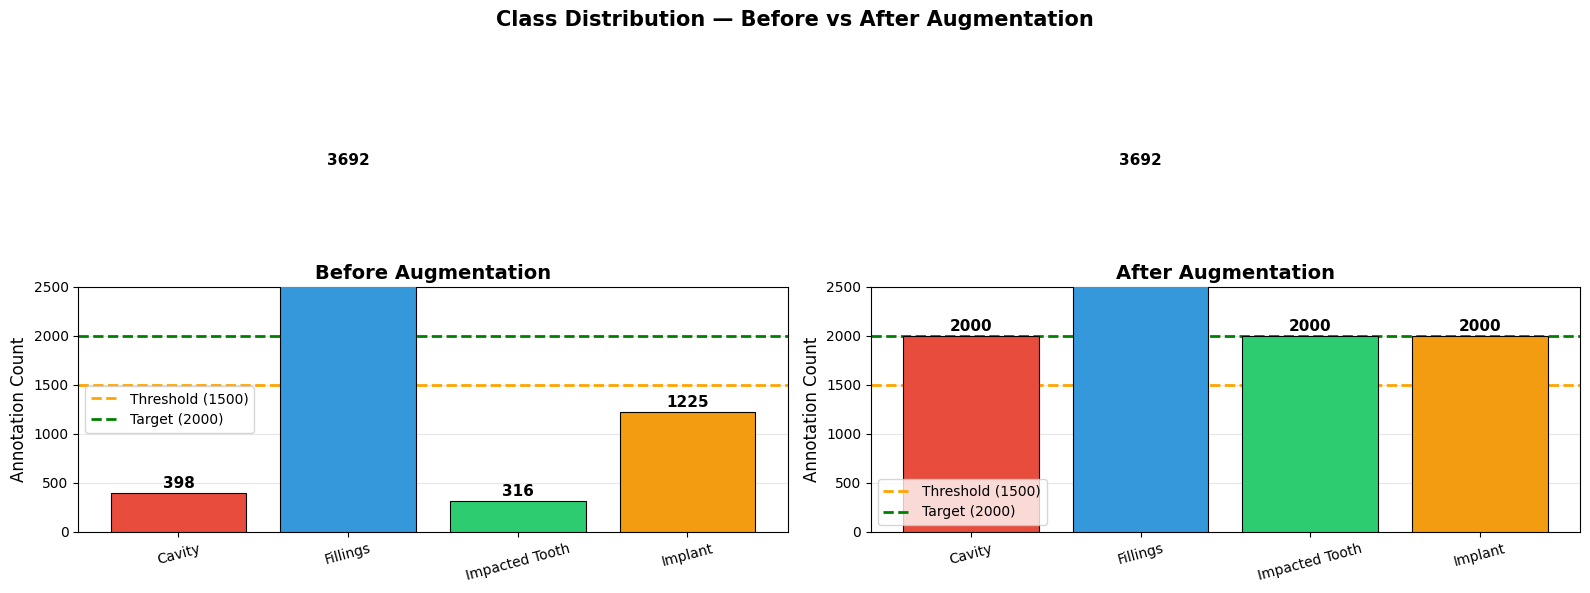

In [10]:
# ── Before vs After Augmentation ─────────────────────────────────────────────
COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
CLS    = CFG['class_names'][1:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define the 'before' counts here!
before = [train_counts.get(c, 0) for c in CLS]

# Map targets by class name so it strictly matches the 4 classes in CLS
name_to_target = {info['name']: info['target'] for info in aug_info.values()}
after = [name_to_target.get(c, 0) for c in CLS]

for ax, data, title in zip(axes, [before, after],
                            ['Before Augmentation', 'After Augmentation']):
    bars = ax.bar(CLS, data, color=COLORS, edgecolor='black', linewidth=0.8, zorder=3)
    ax.axhline(CFG['aug_threshold'], color='orange', ls='--', lw=2,
               label=f"Threshold ({CFG['aug_threshold']})")
    ax.axhline(CFG['aug_target'],    color='green',  ls='--', lw=2,
               label=f"Target ({CFG['aug_target']})")
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Annotation Count', fontsize=12)
    ax.set_ylim(0, CFG['aug_target'] * 1.25)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution — Before vs After Augmentation',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/aug_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ── Albumentations Transforms ─────────────────────────────────────────────────
_bbox_params = A.BboxParams(format='pascal_voc', label_fields=['class_labels'],
                             min_visibility=0.3)

TRANSFORM_BASE = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
], bbox_params=_bbox_params)

TRANSFORM_AUG = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    # ── Geometric ──────────────────────────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15,
                       border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.Affine(shear=(-10, 10), p=0.3),          # simulate patient positioning variation
    # ── Intensity / X-ray domain ───────────────────────────────────────────
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.Equalize(p=0.3),                          # histogram equalisation — common in X-ray preprocessing
    A.RandomToneCurve(scale=0.1, p=0.3),        # simulate exposure variation
    A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.3),  # sharpen dental structures
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),             # local contrast enhancement
    # ── Noise / Blur — kept mild; X-rays have structured noise ────────────
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2), # reduced variance vs default
    A.Blur(blur_limit=3, p=0.2),
    # ── Normalise ──────────────────────────────────────────────────────────
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
], bbox_params=_bbox_params)

TRANSFORM_VAL = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
], bbox_params=_bbox_params)

print("Transforms defined ✅")


Transforms defined ✅


In [12]:
# ── DentalDataset (Path-Sanitized Version) ────────────────────────────────────
class DentalDataset(Dataset):
    def __init__(self, json_path, img_dir, cat_to_label,
                 aug_info=None, base_tfm=None, aug_tfm=None, is_train=False):
        self.coco         = COCO(json_path)
        self.img_dir      = img_dir
        self.cat_to_label = cat_to_label
        self.base_tfm     = base_tfm
        self.aug_tfm      = aug_tfm

        # 1. STRICT FILE CHECK: Verify file exists with a sanitized path
        self.samples = []
        missing_count = 0
        for iid in self.coco.imgs.keys():
            info = self.coco.imgs[iid]
            # FIX: Strip any bad folder paths from the JSON (e.g., 'train/images/img.jpg' -> 'img.jpg')
            safe_fname = os.path.basename(info['file_name'])
            path = os.path.join(self.img_dir, safe_fname)
            
            if os.path.exists(path):
                self.samples.append((iid, False))
            else:
                missing_count += 1
                
        if missing_count > 0:
            print(f"⚠️ Blocked {missing_count} missing images.")
            if len(self.samples) == 0:
                print(f"🚨 CRITICAL: 100% of images are missing! Check if '{self.img_dir}' is the correct Kaggle folder.")

        # 2. SAFE OVERSAMPLING
        if is_train and aug_info and len(self.samples) > 0:
            self._oversample(aug_info)

        random.shuffle(self.samples)
        print(f"  {Path(json_path).parent.name:10s} "
              f"| {len(self.coco.imgs):5d} JSON images "
              f"| {len(self.samples):6d} valid samples queued")

    def _oversample(self, aug_info):
        valid_img_ids = {iid for iid, is_aug in self.samples}
        for lbl, info in aug_info.items():
            if not info['needs_aug'] or info['extra'] == 0:
                continue
            ann_ids  = self.coco.getAnnIds(catIds=[info['cat_id']])
            img_pool = list({a['image_id'] for a in self.coco.loadAnns(ann_ids) 
                             if a['image_id'] in valid_img_ids})
            if not img_pool:
                continue
            need   = info['extra']
            aug_s  = (img_pool * (need // len(img_pool) + 1))[:need]
            self.samples.extend([(iid, True) for iid in aug_s])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, use_aug = self.samples[idx]

        info  = self.coco.imgs[img_id]
        safe_fname = os.path.basename(info['file_name'])
        path  = os.path.join(self.img_dir, safe_fname)
        
        image = cv2.imread(path)
        if image is None:
            image = np.zeros((CFG['img_size'], CFG['img_size'], 3), np.uint8)
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        anns   = self.coco.loadAnns(self.coco.getAnnIds(imgIds=[img_id]))
        h, w   = image.shape[:2]
        boxes, labels = [], []
        
        for ann in anns:
            x, y, bw, bh = ann['bbox']
            x1, y1 = max(0.0, x),   max(0.0, y)
            x2, y2 = min(w, x+bw),  min(h, y+bh)
            # LABEL FILTER
            if x2 > x1 and y2 > y1 and ann['category_id'] in self.cat_to_label:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.cat_to_label[ann['category_id']])

        boxes  = np.array(boxes,  dtype=np.float32) if boxes else np.zeros((0, 4), np.float32)
        labels = list(labels)

        tfm = (self.aug_tfm if use_aug else self.base_tfm) or self.base_tfm
        if tfm is not None:
            try:
                out = tfm(image=image, bboxes=boxes.tolist() if len(boxes) else [], class_labels=labels)
                image  = out['image']
                boxes  = np.array(out['bboxes'], np.float32) if out['bboxes'] else np.zeros((0,4),np.float32)
                labels = list(out['class_labels'])
            except Exception:
                out    = TRANSFORM_VAL(image=image, bboxes=[], class_labels=[])
                image  = out['image']
                boxes  = np.zeros((0,4), np.float32)
                labels = []

        if isinstance(image, np.ndarray):
            image = torch.from_numpy(image.transpose(2,0,1)).float()

        target = {
            'boxes':    torch.as_tensor(boxes,  dtype=torch.float32),
            'labels':   torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([img_id]),
        }
        return image, target

    def raw_sample(self, idx):
        img_id, _ = self.samples[idx]
        info      = self.coco.imgs[img_id]
        safe_fname = os.path.basename(info['file_name'])
        path      = os.path.join(self.img_dir, safe_fname)
        image     = cv2.imread(path)
        if image is None: return None, None
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        anns  = self.coco.loadAnns(self.coco.getAnnIds(imgIds=[img_id]))
        h, w  = image.shape[:2]
        boxes, labels = [], []
        for ann in anns:
            x, y, bw, bh = ann['bbox']
            x1,y1 = max(0,x), max(0,y)
            x2,y2 = min(w,x+bw), min(h,y+bh)
            if x2>x1 and y2>y1 and ann['category_id'] in self.cat_to_label:
                boxes.append([x1,y1,x2,y2])
                labels.append(self.cat_to_label[ann['category_id']])
        return image, {'boxes': boxes, 'labels': labels}

def collate_fn(batch):
    return tuple(zip(*batch))

In [13]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
print("Building datasets...")
train_ds = DentalDataset(CFG['train_json'], CFG['train_img_dir'], CAT_TO_LABEL,
                         aug_info=aug_info, base_tfm=TRANSFORM_BASE,
                         aug_tfm=TRANSFORM_AUG, is_train=True)

val_ds   = DentalDataset(CFG['val_json'],   CFG['val_img_dir'],   CAT_TO_LABEL,
                         base_tfm=TRANSFORM_VAL)

test_ds  = DentalDataset(CFG['test_json'],  CFG['test_img_dir'],  CAT_TO_LABEL,
                         base_tfm=TRANSFORM_VAL)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], collate_fn=collate_fn,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], collate_fn=collate_fn,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], collate_fn=collate_fn,
                          pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}  "
      f"Val batches: {len(val_loader)}  "
      f"Test batches: {len(test_loader)}")


Building datasets...
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
  train      |   753 JSON images |   4814 valid samples queued
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  valid      |   215 JSON images |    215 valid samples queued
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
  test       |   107 JSON images |    107 valid samples queued

Train batches: 1204  Val batches: 54  Test batches: 27


In [14]:
# ── RetinaNet Model ───────────────────────────────────────────────────────────
from torchvision.models.detection import (
    retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
)

def build_retinanet(num_classes, device):
    """
    Build RetinaNet with ResNet-50-FPN-v2 backbone.
    num_classes = number of FOREGROUND classes only (background is implicit).
    FIX: was incorrectly passing num_classes+1 before.
    """
    model = retinanet_resnet50_fpn_v2(weights=RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT)
    in_ch       = model.head.classification_head.conv[0][0].in_channels
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_ch, num_anchors=num_anchors,
        num_classes=num_classes)   # FIX: pass num_classes directly (not +1)
    return model.to(device)

model = build_retinanet(CFG['num_classes'], CFG['device'])   # = 4 foreground classes

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone       : ResNet-50-FPN-v2 (improved training recipe)")
print(f"Total params   : {total:,}")
print(f"Trainable params: {trainable:,}")


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth


100%|██████████| 146M/146M [00:00<00:00, 216MB/s] 


Backbone       : ResNet-50-FPN-v2 (improved training recipe)
Total params   : 36,413,841
Trainable params: 36,188,497


In [15]:
# ── Evaluation Utilities ──────────────────────────────────────────────────────
def iou_single(a, b):
    xi1, yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2, yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area  = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / (area + 1e-7)


def _collect_preds(model, loader, device):
    """Run inference once and cache results."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, targets in loader:
            images  = [img.to(device) for img in images]
            outputs = model(images)
            all_preds.extend([{k: v.cpu() for k, v in o.items()} for o in outputs])
            all_targets.extend(targets)
    return all_preds, all_targets


def _match(all_preds, all_targets, conf_thresh, iou_thresh=0.5):
    """Return per-class TP/FP/FN dicts."""
    TP = defaultdict(int); FP = defaultdict(int); FN = defaultdict(int)
    for pred, tgt in zip(all_preds, all_targets):
        mask  = pred['scores'] >= conf_thresh
        pboxes, plabels = pred['boxes'][mask].numpy(), pred['labels'][mask].numpy()
        gboxes, glabels = tgt['boxes'].numpy(), tgt['labels'].numpy()
        matched = set()
        for pb, pl in zip(pboxes, plabels):
            best_iou, best_j = 0, -1
            for j, (gb, gl) in enumerate(zip(gboxes, glabels)):
                if j in matched or gl != pl: continue
                iou = iou_single(pb, gb)
                if iou > best_iou: best_iou, best_j = iou, j
            if best_iou >= iou_thresh:
                TP[pl] += 1; matched.add(best_j)
            else:
                FP[pl] += 1
        for j, gl in enumerate(glabels):
            if j not in matched: FN[gl] += 1
    return TP, FP, FN


def evaluate_prf(all_preds, all_targets, conf_thresh=0.3, iou_thresh=0.5):
    """Mean precision, recall, F1 + per-class dict."""
    TP, FP, FN = _match(all_preds, all_targets, conf_thresh, iou_thresh)
    metrics = {}
    for lbl in range(1, CFG['num_classes']+1):
        tp, fp, fn = TP[lbl], FP[lbl], FN[lbl]
        p  = tp / (tp+fp+1e-7)
        r  = tp / (tp+fn+1e-7)
        f1 = 2*p*r / (p+r+1e-7)
        metrics[lbl] = dict(precision=p, recall=r, f1=f1, TP=tp, FP=fp, FN=fn)
    mp  = np.mean([m['precision'] for m in metrics.values()])
    mr  = np.mean([m['recall']    for m in metrics.values()])
    mf1 = np.mean([m['f1']        for m in metrics.values()])
    return mp, mr, mf1, metrics


def evaluate_map(model, loader, device, coco_gt):
    """mAP@0.5 and mAP@0.5:0.95 via pycocotools."""
    model.eval()
    results = []
    with torch.no_grad():
        for images, targets in loader:
            images  = [img.to(device) for img in images]
            outputs = model(images)
            for pred, tgt in zip(outputs, targets):
                iid = tgt['image_id'].item()
                for box, lbl, sc in zip(pred['boxes'], pred['labels'], pred['scores']):
                    x1,y1,x2,y2 = box.tolist()
                    results.append(dict(image_id=iid,
                                        category_id=LABEL_TO_CAT[lbl.item()],
                                        bbox=[x1, y1, x2-x1, y2-y1],
                                        score=sc.item()))
    if not results:
        return 0.0, 0.0
    coco_dt = coco_gt.loadRes(results)
    ev = COCOeval(coco_gt, coco_dt, 'bbox')
    ev.evaluate(); ev.accumulate(); ev.summarize()
    return float(ev.stats[1]), float(ev.stats[0])   # mAP50, mAP50-95

coco_val_gt  = COCO(CFG['val_json'])
coco_test_gt = COCO(CFG['test_json'])
print("Evaluation utilities ready ✅")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Evaluation utilities ready ✅


In [16]:
# ── Training Loop ─────────────────────────────────────────────────────────────
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CFG['lr'], weight_decay=CFG['weight_decay'])

# FIX: Cosine annealing replaces the aggressive MultiStep schedule
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['num_epochs'], eta_min=1e-6)

# Mixed-precision scaler (no-op on CPU)
scaler = GradScaler(enabled=(CFG['device'] == 'cuda'))

history = dict(train_loss=[], cls_loss=[], reg_loss=[],
               val_map50=[], val_map5095=[],
               val_precision=[], val_recall=[], val_f1=[], lr=[])

best_map50   = 0.0
no_improve   = 0          # early-stopping counter
PATIENCE     = CFG['patience']

print("🚀  Training started\n" + "="*75)

for epoch in range(1, CFG['num_epochs'] + 1):
    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    e_loss = e_cls = e_reg = 0.0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{CFG['num_epochs']}")

    for step, (images, targets) in enumerate(pbar):
        images  = [img.to(CFG['device']) for img in images]
        targets = [{k: v.to(CFG['device']) for k, v in t.items()
                    if k in ('boxes','labels')} for t in targets]
        valid   = [(im, tg) for im, tg in zip(images, targets) if len(tg['boxes'])]
        if not valid:
            if step % 50 == 0:
                print(f"  ⚠️  Empty batch at step {step} — check oversampling")
            continue
        imgs_v, tgts_v = zip(*valid)

        # FIX: Mixed-precision forward + backward
        with autocast(enabled=(CFG['device'] == 'cuda')):
            loss_d = model(list(imgs_v), list(tgts_v))
            cls_l  = loss_d.get('classification',  torch.tensor(0., device=CFG['device']))
            reg_l  = loss_d.get('bbox_regression', torch.tensor(0., device=CFG['device']))
            loss   = cls_l + reg_l

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        e_loss += loss.item(); e_cls += cls_l.item(); e_reg += reg_l.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    nb_steps = max(len(train_loader), 1)
    avg_loss = e_loss/nb_steps; avg_cls = e_cls/nb_steps; avg_reg = e_reg/nb_steps

    # ── validate — single inference pass shared by both metrics ───────────
    preds_v, tgts_v = _collect_preds(model, val_loader, CFG['device'])

    # mAP via pycocotools (re-uses cached preds to avoid a 2nd loader pass)
    results = []
    for pred, tgt in zip(preds_v, tgts_v):
        iid = tgt['image_id'].item()
        for box, lbl, sc in zip(pred['boxes'], pred['labels'], pred['scores']):
            x1,y1,x2,y2 = box.tolist()
            results.append(dict(image_id=iid,
                                category_id=LABEL_TO_CAT[lbl.item()],
                                bbox=[x1, y1, x2-x1, y2-y1],
                                score=sc.item()))
    if results:
        coco_dt       = coco_val_gt.loadRes(results)
        ev            = COCOeval(coco_val_gt, coco_dt, 'bbox')
        ev.evaluate(); ev.accumulate(); ev.summarize()
        map50, map5095 = float(ev.stats[1]), float(ev.stats[0])
    else:
        map50 = map5095 = 0.0

    mp, mr, mf1, _ = evaluate_prf(preds_v, tgts_v, CFG['conf_threshold'])

    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(avg_loss); history['cls_loss'].append(avg_cls)
    history['reg_loss'].append(avg_reg);    history['val_map50'].append(map50)
    history['val_map5095'].append(map5095); history['val_precision'].append(mp)
    history['val_recall'].append(mr);       history['val_f1'].append(mf1)
    history['lr'].append(cur_lr)

    print(f"Epoch {epoch:02d}/{CFG['num_epochs']} | "
          f"loss {avg_loss:.4f} (cls {avg_cls:.4f} reg {avg_reg:.4f}) | "
          f"mAP50 {map50:.4f} | mAP50-95 {map5095:.4f} | "
          f"P {mp:.4f} R {mr:.4f} F1 {mf1:.4f} | "
          f"lr {cur_lr:.2e} | {time.time()-t0:.1f}s")

    # ── checkpoint + early stopping ────────────────────────────────────────
    if map50 > best_map50:
        best_map50 = map50
        no_improve = 0
        torch.save(dict(epoch=epoch, model_state_dict=model.state_dict(),
                        map50=map50, history=history),
                   f"{CFG['save_dir']}/best_model.pth")
        print(f"  💾 saved best model (mAP50={map50:.4f})")
    else:
        no_improve += 1
        print(f"  ⏳ no improvement {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print(f"\n🛑  Early stopping triggered at epoch {epoch}  "
                  f"(best mAP50={best_map50:.4f})")
            break

with open(f"{CFG['save_dir']}/history.json", 'w') as f:
    json.dump(history, f)
print(f"\n✅  Training done!  Best mAP@0.5 = {best_map50:.4f}")


🚀  Training started


Epoch 01/50:   0%|          | 0/1204 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.42s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.449
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.743
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.498
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.251
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.450
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.800
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.215
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.573
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.642
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

Epoch 02/50:   0%|          | 0/1204 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Load Best Model ───────────────────────────────────────────────────────────
ckpt = torch.load(f"{CFG['save_dir']}/best_model.pth", map_location=CFG['device'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']}  mAP50={ckpt['map50']:.4f}")

# cache predictions for all downstream visualisations ──────────────────────
print("Running inference on val set (cached for all visualisations)...")
val_preds, val_tgts = _collect_preds(model, val_loader, CFG['device'])
print("Done ✅")


In [ ]:
# ── Loss Curves ───────────────────────────────────────────────────────────────
ep = range(1, len(history['train_loss'])+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Loss Curves', fontsize=16, fontweight='bold')

for ax, key, color, title in zip(
        axes,
        ['train_loss', 'cls_loss', 'reg_loss'],
        ['royalblue', 'crimson', 'seagreen'],
        ['Total Loss', 'Classification Loss', 'Regression (BBox) Loss']):
    ax.plot(ep, history[key], color=color, lw=2.5, marker='o', markersize=4)
    ax.fill_between(ep, history[key], alpha=0.15, color=color)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    best_val = min(history[key])
    best_ep  = history[key].index(best_val) + 1
    ax.axvline(best_ep, color='gray', ls=':', lw=1.5)
    ax.annotate(f'min={best_val:.4f}', xy=(best_ep, best_val),
                xytext=(5, 10), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Metrics vs Epoch ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Validation Metrics vs Epoch', fontsize=16, fontweight='bold')

# mAP
axes[0][0].plot(ep, history['val_map50'],   'b-o', ms=4, lw=2, label='mAP@0.5')
axes[0][0].plot(ep, history['val_map5095'], 'g-s', ms=4, lw=2, label='mAP@0.5:0.95')
axes[0][0].set_title('mAP vs Epoch', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Epoch'); axes[0][0].set_ylabel('mAP')
axes[0][0].legend(); axes[0][0].grid(alpha=0.3); axes[0][0].set_ylim(0, 1)

# Precision
axes[0][1].plot(ep, history['val_precision'], 'r-^', ms=4, lw=2, label='Precision')
axes[0][1].set_title('Precision vs Epoch', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Epoch'); axes[0][1].set_ylabel('Precision')
axes[0][1].legend(); axes[0][1].grid(alpha=0.3); axes[0][1].set_ylim(0, 1)

# Recall
axes[1][0].plot(ep, history['val_recall'], 'm-D', ms=4, lw=2, label='Recall')
axes[1][0].set_title('Recall vs Epoch', fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Epoch'); axes[1][0].set_ylabel('Recall')
axes[1][0].legend(); axes[1][0].grid(alpha=0.3); axes[1][0].set_ylim(0, 1)

# All together
axes[1][1].plot(ep, history['val_map50'],     'b-o', ms=3, lw=2, label='mAP@0.5')
axes[1][1].plot(ep, history['val_precision'], 'r-^', ms=3, lw=2, label='Precision')
axes[1][1].plot(ep, history['val_recall'],    'm-D', ms=3, lw=2, label='Recall')
axes[1][1].plot(ep, history['val_f1'],        'g-s', ms=3, lw=2, label='F1')
axes[1][1].set_title('All Metrics vs Epoch', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Epoch'); axes[1][1].set_ylabel('Score')
axes[1][1].legend(); axes[1][1].grid(alpha=0.3); axes[1][1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/metrics_vs_epoch.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Precision-Recall Curves ───────────────────────────────────────────────────
def pr_curve_class(preds, targets, class_label, n_thresholds=60):
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    Ps, Rs = [], []
    for th in thresholds:
        TP=FP=FN=0
        for pred, tgt in zip(preds, targets):
            mask  = pred['scores'] >= th
            pboxes = pred['boxes'][mask].numpy()
            plabels= pred['labels'][mask].numpy()
            gboxes = tgt['boxes'].numpy()
            glabels= tgt['labels'].numpy()
            matched = set()
            for pb, pl in zip(pboxes, plabels):
                if pl != class_label: continue
                best_iou, best_j = 0, -1
                for j, (gb, gl) in enumerate(zip(gboxes, glabels)):
                    if j in matched or gl != class_label: continue
                    iou = iou_single(pb, gb)
                    if iou > best_iou: best_iou, best_j = iou, j
                if best_iou >= CFG['iou_threshold']:
                    TP += 1; matched.add(best_j)
                else:
                    FP += 1
            for j, gl in enumerate(glabels):
                if gl == class_label and j not in matched: FN += 1
        Ps.append(TP/(TP+FP+1e-7))
        Rs.append(TP/(TP+FN+1e-7))
    return np.array(Ps), np.array(Rs)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Precision-Recall Curves', fontsize=16, fontweight='bold')

all_pr = {}
for i, (lbl, name) in enumerate(zip(range(1, CFG['num_classes']+1), CFG['class_names'][1:])):
    P, R = pr_curve_class(val_preds, val_tgts, lbl)
    all_pr[name] = (P, R)
    order = np.argsort(R)
    ap    = np.trapz(P[order], R[order])
    for ax in axes:
        ax.plot(R[order], P[order], color=COLORS[i], lw=2.5,
                label=f'{name} (AP={ap:.3f})')

for ax in axes:
    ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

axes[0].set_title('PR Curve — per Class', fontsize=13, fontweight='bold')
axes[1].set_title('PR Curves — Comparison', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── F1-Confidence Curve ───────────────────────────────────────────────────────
def f1_vs_confidence(preds, targets, n_thresholds=60):
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    cls_f1s = {n: [] for n in CFG['class_names'][1:]}
    mean_f1s = []

    for th in thresholds:
        TP = defaultdict(int); FP = defaultdict(int); FN = defaultdict(int)
        for pred, tgt in zip(preds, targets):
            mask    = pred['scores'] >= th
            pboxes  = pred['boxes'][mask].numpy()
            plabels = pred['labels'][mask].numpy()
            gboxes  = tgt['boxes'].numpy()
            glabels = tgt['labels'].numpy()
            matched = set()
            for pb, pl in zip(pboxes, plabels):
                best_iou, best_j = 0, -1
                for j, (gb, gl) in enumerate(zip(gboxes, glabels)):
                    if j in matched or gl != pl: continue
                    iou = iou_single(pb, gb)
                    if iou > best_iou: best_iou, best_j = iou, j
                if best_iou >= CFG['iou_threshold']:
                    TP[pl] += 1; matched.add(best_j)
                else:
                    FP[pl] += 1
            for j, gl in enumerate(glabels):
                if j not in matched: FN[gl] += 1

        row = []
        for lbl, name in zip(range(1, CFG['num_classes']+1), CFG['class_names'][1:]):
            tp, fp, fn = TP[lbl], FP[lbl], FN[lbl]
            p  = tp/(tp+fp+1e-7); r = tp/(tp+fn+1e-7)
            f1 = 2*p*r/(p+r+1e-7)
            cls_f1s[name].append(f1); row.append(f1)
        mean_f1s.append(np.mean(row))

    return thresholds, cls_f1s, mean_f1s

thresholds, cls_f1s, mean_f1s = f1_vs_confidence(val_preds, val_tgts)
best_idx   = int(np.argmax(mean_f1s))
best_conf  = thresholds[best_idx]
best_f1    = mean_f1s[best_idx]

fig, ax = plt.subplots(figsize=(12, 7))
for i, (name, f1s) in enumerate(cls_f1s.items()):
    ax.plot(thresholds, f1s, color=COLORS[i], lw=2.5, label=name)
ax.plot(thresholds, mean_f1s, 'k--', lw=3,
        label=f'Mean  (best F1={best_f1:.3f} @ conf={best_conf:.2f})')
ax.axvline(best_conf, color='gray', ls=':', lw=2)
ax.scatter([best_conf], [best_f1], color='black', s=120, zorder=5)
ax.set_xlabel('Confidence Threshold', fontsize=13)
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title('F1-Confidence Curve', fontsize=15, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/f1_confidence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Best confidence threshold: {best_conf:.3f}  →  F1 = {best_f1:.4f}")

# FIX: Update CFG with the optimal confidence threshold found above
# All downstream evaluation (confusion matrix, per-class metrics, test set) will use it
CFG['conf_threshold'] = float(best_conf)
print(f"✅  CFG['conf_threshold'] updated → {CFG['conf_threshold']:.3f}")


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
def confusion_matrix_det(preds, targets, num_cls, conf_thresh, iou_thresh=0.5):
    """
    Shape: (num_cls+1) × (num_cls+1)
    Row = Actual   (0 = background / FN)
    Col = Predicted (0 = background / FP)
    """
    cm = np.zeros((num_cls+1, num_cls+1), int)
    for pred, tgt in zip(preds, targets):
        mask    = pred['scores'] >= conf_thresh
        pboxes  = pred['boxes'][mask].numpy()
        plabels = pred['labels'][mask].numpy()
        gboxes  = tgt['boxes'].numpy()
        glabels = tgt['labels'].numpy()
        matched_gt = set(); matched_pred = set()

        for i, (pb, pl) in enumerate(zip(pboxes, plabels)):
            best_iou, best_j, best_gl = 0, -1, 0
            for j, (gb, gl) in enumerate(zip(gboxes, glabels)):
                if j in matched_gt: continue
                iou = iou_single(pb, gb)
                if iou > best_iou: best_iou, best_j, best_gl = iou, j, gl
            if best_iou >= iou_thresh:
                cm[best_gl][pl] += 1
                matched_gt.add(best_j); matched_pred.add(i)
            else:
                cm[0][pl] += 1          # FP

        for j, gl in enumerate(glabels):
            if j not in matched_gt:
                cm[gl][0] += 1          # FN
    return cm

cm = confusion_matrix_det(val_preds, val_tgts,
                           CFG['num_classes'], CFG['conf_threshold'])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
labels_full = ['Background'] + CFG['class_names'][1:]

# raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_full, yticklabels=labels_full,
            linewidths=0.5, ax=axes[0], cbar=True)
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual',    fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix  (Counts)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# normalised
cm_norm = cm.astype(float)
rs = cm_norm.sum(axis=1, keepdims=True); rs[rs==0] = 1
cm_norm /= rs
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_full, yticklabels=labels_full,
            linewidths=0.5, ax=axes[1], cbar=True, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual',    fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix  (Normalised)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix — Validation Set', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Per-Class Metrics Bar Chart ───────────────────────────────────────────────
_, _, _, per_cls_metrics = evaluate_prf(val_preds, val_tgts, CFG['conf_threshold'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Per-Class Metrics — Validation Set', fontsize=16, fontweight='bold')

for ax, metric, color, title in zip(
        axes,
        ['precision', 'recall', 'f1'],
        ['#E74C3C', '#3498DB', '#2ECC71'],
        ['Precision', 'Recall', 'F1 Score']):
    vals = [per_cls_metrics[l][metric] for l in range(1, CFG['num_classes']+1)]
    bars = ax.bar(CFG['class_names'][1:], vals, color=color,
                  edgecolor='black', lw=0.8, alpha=0.85)
    ax.set_ylim(0, 1.15); ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Learning Rate Schedule ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep, history['lr'], 'b-o', ms=5, lw=2)
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax.set_yscale('log'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/lr_schedule.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Sample Predictions Helper ─────────────────────────────────────────────────
def show_predictions(model, dataset, device, conf_thresh=None, n=8, title=''):
    conf_thresh = conf_thresh or CFG['conf_threshold']
    model.eval()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    names = CFG['class_names']

    # pick n random samples that have GT annotations
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    chosen = []
    with torch.no_grad():
        for idx in indices:
            img, tgt = dataset[idx]
            if len(tgt['boxes']) == 0: continue
            out = model([img.to(device)])[0]
            chosen.append((img, tgt, out))
            if len(chosen) >= n: break

    nrows, ncols = 2, n // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5.5))
    fig.suptitle(title or 'Predictions  (dashed green = GT, solid = prediction)',
                 fontsize=14, fontweight='bold')

    for k, (img, tgt, out) in enumerate(chosen[:nrows*ncols]):
        ax = axes[k // ncols][k % ncols]
        vis = (img * std + mean).permute(1,2,0).numpy().clip(0,1)
        ax.imshow(vis)

        # GT (dashed lime)
        for box, lbl in zip(tgt['boxes'], tgt['labels']):
            x1,y1,x2,y2 = box.tolist()
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                         lw=2, edgecolor='lime', facecolor='none', ls='--'))
            ax.text(x1, y2+3, f"GT:{names[lbl.item()]}",
                    color='lime', fontsize=6,
                    bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.55))

        # Predictions (solid)
        mask = out['scores'] >= conf_thresh
        for box, lbl, sc in zip(out['boxes'][mask], out['labels'][mask], out['scores'][mask]):
            x1,y1,x2,y2 = box.tolist()
            c = COLORS[(lbl.item()-1) % 4]
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                         lw=2.5, edgecolor=c, facecolor='none'))
            ax.text(x1, y1-4, f"{names[lbl.item()]} {sc:.2f}",
                    color=c, fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75))
        ax.set_title(f'Sample {k+1}', fontsize=9); ax.axis('off')

    plt.tight_layout()
    safe = title.replace(' ','_').lower()
    plt.savefig(f"{CFG['save_dir']}/predictions_{safe}.png", dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Validation Predictions ────────────────────────────────────────────────────
show_predictions(model, val_ds, CFG['device'], title='Validation Set')


In [ ]:
# ── Test Set Predictions ──────────────────────────────────────────────────────
show_predictions(model, test_ds, CFG['device'], title='Test Set')


In [ ]:
# ── Final Evaluation on Test Set ─────────────────────────────────────────────
map50_test, map5095_test = evaluate_map(model, test_loader, CFG['device'], coco_test_gt)
test_preds_c, test_tgts_c = _collect_preds(model, test_loader, CFG['device'])
mp, mr, mf1, per_cls_test = evaluate_prf(test_preds_c, test_tgts_c, CFG['conf_threshold'])

print("\n" + "="*55)
print(f"  FINAL TEST RESULTS")
print("="*55)
print(f"  mAP@0.5        : {map50_test:.4f}")
print(f"  mAP@0.5:0.95   : {map5095_test:.4f}")
print(f"  Mean Precision : {mp:.4f}")
print(f"  Mean Recall    : {mr:.4f}")
print(f"  Mean F1        : {mf1:.4f}")
print("-"*55)
print(f"{'Class':<20} {'P':>8} {'R':>8} {'F1':>8}")
print("-"*55)
for lbl, name in zip(range(1, CFG['num_classes']+1), CFG['class_names'][1:]):
    m = per_cls_test[lbl]
    print(f"{name:<20} {m['precision']:>8.4f} {m['recall']:>8.4f} {m['f1']:>8.4f}")
print("="*55)


In [ ]:
# ── Full Dashboard ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(26, 20))
gs  = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('RetinaNet — Dental X-Ray Detection  |  Full Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

ep_r = list(range(1, len(history['train_loss'])+1))

# ── row 0 ──────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(ep_r, history['train_loss'], 'b-', lw=2, label='Total')
ax.plot(ep_r, history['cls_loss'],   'r--',lw=1.5, label='Class')
ax.plot(ep_r, history['reg_loss'],   'g:',  lw=1.5, label='Reg')
ax.set_title('Loss Curves', fontweight='bold'); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 1])
ax.plot(ep_r, history['val_map50'],   'b-o', ms=3, lw=2, label='mAP@0.5')
ax.plot(ep_r, history['val_map5095'], 'g-s', ms=3, lw=2, label='mAP@0.5:0.95')
ax.set_title('mAP vs Epoch', fontweight='bold'); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

ax = fig.add_subplot(gs[0, 2])
ax.plot(ep_r, history['val_precision'], 'r-^', ms=3, lw=2, label='Precision')
ax.plot(ep_r, history['val_recall'],    'b-D', ms=3, lw=2, label='Recall')
ax.plot(ep_r, history['val_f1'],        'g-s', ms=3, lw=2, label='F1')
ax.set_title('P / R / F1 vs Epoch', fontweight='bold'); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

ax = fig.add_subplot(gs[0, 3])
for i, (name, f1s) in enumerate(cls_f1s.items()):
    ax.plot(thresholds, f1s, color=COLORS[i], lw=2, label=name)
ax.plot(thresholds, mean_f1s, 'k--', lw=2.5, label='Mean')
ax.axvline(best_conf, color='gray', ls=':', lw=1.5)
ax.set_title('F1-Confidence', fontweight='bold')
ax.set_xlabel('Confidence'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── row 1 ──────────────────────────────────────────────────────────────────
for col, (metric, color, title) in enumerate(zip(
        ['precision','recall','f1'],
        ['#E74C3C','#3498DB','#2ECC71'],
        ['Per-Class Precision','Per-Class Recall','Per-Class F1'])):
    ax = fig.add_subplot(gs[1, col])
    vals = [per_cls_metrics[l][metric] for l in range(1, CFG['num_classes']+1)]
    ax.bar(CFG['class_names'][1:], vals, color=color, edgecolor='black', lw=0.6)
    ax.set_title(title, fontweight='bold'); ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)

ax = fig.add_subplot(gs[1, 3])
before_c = [train_counts.get(c, 0) for c in CFG['class_names'][1:]]
after_c  = [aug_info[CAT_TO_LABEL[cid]]['target'] for cid in cat_ids]
x = np.arange(len(CFG['class_names'][1:]))
ax.bar(x-0.2, before_c, 0.35, label='Before', color='#BDC3C7', edgecolor='black', lw=0.6)
ax.bar(x+0.2, after_c,  0.35, label='After',  color='#3498DB', edgecolor='black', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([n[:4] for n in CFG['class_names'][1:]])
ax.set_title('Before/After Augmentation', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# ── row 2 ──────────────────────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[2, :2])
for i, (name, (P, R)) in enumerate(all_pr.items()):
    order = np.argsort(R)
    ax_pr.plot(R[order], P[order], color=COLORS[i], lw=2.5, label=name)
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves', fontweight='bold')
ax_pr.legend(fontsize=9); ax_pr.grid(alpha=0.3)
ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1)

ax_cm = fig.add_subplot(gs[2, 2:])
cm_n = cm.astype(float); rs = cm_n.sum(axis=1, keepdims=True); rs[rs==0]=1; cm_n/=rs
short = ['BG'] + [n[:4] for n in CFG['class_names'][1:]]
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short, yticklabels=short,
            linewidths=0.5, ax=ax_cm, cbar=False)
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')
ax_cm.set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.savefig(f"{CFG['save_dir']}/full_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Dashboard saved!")


In [ ]:
# ── Output Files Summary ──────────────────────────────────────────────────────
print("\n📁 Generated files:")
print("-" * 50)
for fname in sorted(os.listdir(CFG['save_dir'])):
    fpath = os.path.join(CFG['save_dir'], fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f"  {fname:<40}  {size:.2f} MB")


In [ ]:
!pip install -q google-api-python-client google-auth google-auth-httplib2

import json, os, zipfile, shutil
from tqdm.auto import tqdm
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

# ── Step 1: Load credentials ──────────────────────────────────────────────────
CRED_PATH = '/kaggle/input/datasets/yousseforabi/kaggle-output-downloader/gdrive.json'
with open(CRED_PATH, 'r') as f:
    cred_data = json.load(f)['default']

creds = Credentials(
    token         = cred_data['access_token'],
    refresh_token = cred_data['refresh_token'],
    token_uri     = cred_data['token_uri'],
    client_id     = cred_data['client_id'],
    client_secret = cred_data['client_secret'],
    scopes        = cred_data['scopes'],
)
creds.refresh(Request())
print('✅ Token refreshed successfully')

# ── Step 2: Build Drive service ───────────────────────────────────────────────
service = build('drive', 'v3', credentials=creds)
print('✅ Drive service ready')

# ── Step 3: Collect all result files into retina_outputs/ folder ──────────────
WORKING_DIR  = '/kaggle/working'
OUTPUT_DIR   = os.path.join(WORKING_DIR, 'retina_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# All files produced by this script
RESULT_FILES = [
    'best_model.pth',
    'history.json',
    'loss_curves.png',
    'metrics_vs_epoch.png',
    'pr_curves.png',
    'f1_confidence.png',
    'confusion_matrix.png',
    'per_class_metrics.png',
    'lr_schedule.png',
    'val_predictions.png',
    'test_predictions.png',
    'dashboard.png',
]

copied, missing = [], []
for fname in RESULT_FILES:
    src = os.path.join(WORKING_DIR, fname)
    dst = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied.append(fname)
    else:
        missing.append(fname)

print(f'\n📂 retina_outputs/ contents ({len(copied)} files):')
for f in copied:
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024**2
    print(f'   ✅  {f:<35} {size_mb:.2f} MB')

if missing:
    print(f'\n⚠️  {len(missing)} files not found (may not have been generated):')
    for f in missing:
        print(f'   ❌  {f}')

# ── Step 4: Zip retina_outputs/ preserving the folder ────────────────────────
zip_path  = os.path.join(WORKING_DIR, 'retina_outputs.zip')
all_files = []
for root, dirs, files in os.walk(OUTPUT_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f'\n📁 Zipping {len(all_files)} files...')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file_path in tqdm(all_files, desc='📦 Zipping'):
        # arcname keeps the retina_outputs/ folder intact inside the zip
        arcname = os.path.relpath(file_path, WORKING_DIR)
        zf.write(file_path, arcname)

zip_size = os.path.getsize(zip_path) / 1024**2
print(f'✅ Zip ready — {zip_size:.1f} MB')
print(f'   Structure inside zip: retina_outputs/<files>')

# ── Step 5: Upload to Google Drive ───────────────────────────────────────────
FOLDER_ID  = '18qN6Yp8IUfq64oA7qCe0QXMdz2SoR8SB'
chunk_size = 5 * 1024 * 1024
file_size  = os.path.getsize(zip_path)

media    = MediaFileUpload(zip_path, mimetype='application/zip',
                           chunksize=chunk_size, resumable=True)
metadata = {'name': 'retina_outputs.zip', 'parents': [FOLDER_ID]}
request  = service.files().create(body=metadata, media_body=media, fields='id')

with tqdm(total=file_size, desc='🚀 Uploading', unit='B',
          unit_scale=True, unit_divisor=1024) as pbar:
    response = None
    prev     = 0
    while response is None:
        status, response = request.next_chunk()
        if status:
            pbar.update(int(status.resumable_progress) - prev)
            prev = int(status.resumable_progress)
    pbar.n = file_size
    pbar.refresh()

file_id = response.get('id')
print(f'\n✅ Uploaded → retina_outputs.zip')
print(f'🔗 https://drive.google.com/file/d/{file_id}/view')
print(f'\n📦 When unzipped you will get:')
print(f'   retina_outputs/')
for f in copied:
    print(f'   ├── {f}')